# Examen Final — Programación 1 (F12)
## Análisis de Datos Sísmicos con la API del USGS

**Nombre:**  Joselin Liseth Tzunux Coxaj  
**Carnet:**        202606884  
**Fecha:**    16/05/2026
**Punteo total:** 100 puntos

---

| Ejercicio | Tema | Puntos |
|---|---|:---:|
| 1a | Cargar datos con `pd.read_csv()` desde URL | 10 |
| 1b | Explorar el DataFrame con un ciclo `for` | 10 |
| 2a | Encontrar el sismo más intenso con un ciclo `for` | 10 |
| 2b | Top 5 sismos más profundos con pandas | 10 |
| 3a | Función `clasificar_sismo()` con condicionales | 15 |
| 3b | Agregar columna de categoría y agrupar con `groupby` | 10 |
| 4a | Función `analizar_sismos()` que retorna un diccionario | 15 |
| 4b | Tres visualizaciones con matplotlib/seaborn | 20 |
| | **Total** | **100** |

---

> **Instrucciones generales**
> - Completa cada ejercicio en la celda indicada.
> - Ejecuta las celdas **en orden** de arriba hacia abajo.
> - Puedes consultar tus apuntes y el enunciado del examen en U Virtual.
> - Entrega el notebook con **todas las celdas ejecutadas** (con output visible).
> - Sube el archivo a tu repositorio en GitHub y envía el enlace a U Virtual.


---
## Contexto: ¿Qué es un terremoto y cómo se mide?

Un **terremoto** ocurre cuando dos placas tectónicas se deslizan bruscamente entre sí,
liberando energía en forma de ondas sísmicas que se propagan por la tierra.

### Magnitud — escala de intensidad

La magnitud mide la energía liberada. La relación es **logarítmica**:
un sismo de magnitud 7.0 libera ~32 veces más energía que uno de 6.0.

| Magnitud | Categoría | Frecuencia aproximada (global) |
|---|---|---|
| < 5.5 | Ligero | Miles por año |
| 5.5 – 5.9 | Moderado-Fuerte | ~500 por año |
| 6.0 – 6.9 | Fuerte | ~130 por año |
| 7.0 – 7.9 | Mayor | ~15 por año |
| ≥ 8.0 | Gran terremoto | 1–2 por año |

### Profundidad del foco

La **profundidad** (columna `depth`) indica dónde ocurrió la ruptura:
- **Superficial** (< 70 km): generalmente más destructivo
- **Intermedio** (70–300 km): daños moderados
- **Profundo** (> 300 km): raramente destructivo en superficie


---
## El dataset: USGS Earthquake Catalog

**Fuente:** United States Geological Survey — [earthquake.usgs.gov](https://earthquake.usgs.gov)

El USGS monitorea la actividad sísmica global en tiempo real y publica todos los
registros de forma abierta. Su API permite descargar datos históricos directamente
como CSV, **sin necesidad de API key**.

Los datos de este examen contienen todos los sismos de **magnitud ≥ 5.5 registrados
en el primer semestre de 2024** (aproximadamente 700 eventos).

### Columnas principales

| Columna | Tipo | Descripción |
|---|---|---|
| `time` | str | Fecha y hora UTC del evento |
| `mag` | float | Magnitud del sismo |
| `depth` | float | Profundidad del foco en kilómetros |
| `magType` | str | Escala usada (`mww`, `mb`, `ml`, …) |
| `place` | str | Descripción de la ubicación |
| `latitude` | float | Latitud del epicentro |
| `longitude` | float | Longitud del epicentro |

### URL del dataset

```
https://earthquake.usgs.gov/fdsnws/event/1/query
    ?format=csv
    &starttime=2024-01-01
    &endtime=2024-06-30
    &minmagnitude=5.5
```

> `pd.read_csv()` acepta URLs directamente — no necesitas descargar el archivo.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

URL_SISMOS = (
    "https://earthquake.usgs.gov/fdsnws/event/1/query"
    "?format=csv"
    "&starttime=2024-01-01"
    "&endtime=2024-06-30"
    "&minmagnitude=5.5"
)

print("Librerias importadas correctamente.")
print(f"URL: {URL_SISMOS}")


Librerias importadas correctamente.
URL: https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&starttime=2024-01-01&endtime=2024-06-30&minmagnitude=5.5


---
## Identificación del estudiante

Completa tu nombre y carnet en la siguiente celda y **ejecútala antes de comenzar**.


In [2]:
# Completa tus datos
NOMBRE = "Joselin Liseth Tzunux Coxaj"   # TU NOMBRE AQUI
CARNET = "202606884"         # TU CARNET AQUI

if NOMBRE == "Nombre Apellido" or CARNET == "202300000":
    raise ValueError("Completa tu nombre y carnet antes de continuar.")

print(f"Estudiante : {NOMBRE}")
print(f"Carnet     : {CARNET}")


Estudiante : Joselin Liseth Tzunux Coxaj
Carnet     : 202606884


---
## Ejercicio 1 — Cargar y explorar los datos (20 pts)

### Parte a) — Cargar el CSV desde la URL (10 pts)

`pandas.read_csv()` puede cargar datos directamente desde una URL,
igual que desde un archivo local. El resultado es un **DataFrame**.

Carga los datos usando `URL_SISMOS` (ya definida arriba) y guárdalos en la
variable `sismos`. Luego muestra:
- Las primeras 5 filas con `.head()`
- Las dimensiones con `.shape`
- Los tipos de datos con `.dtypes`
- Los valores nulos con `.isnull().sum()`


In [3]:
# Carga el CSV desde URL_SISMOS con pd.read_csv() y guárdalo en 'sismos'
sismos = pd.read_csv(URL_SISMOS)  # TU CÓDIGO AQUÍ

# Muestra las primeras 5 filas
# TU CÓDIGO AQUÍ
print(sismos.head())
# Muestra las dimensiones (shape)
# TU CÓDIGO AQUÍ
print(sismos.shape)
# Muestra los tipos de datos (dtypes)
# TU CÓDIGO AQUÍ
print(sismos.dtypes)
# Verifica valores nulos con isnull().sum()
# TU CÓDIGO AQUÍ
print(sismos.isnull().sum())

                       time  latitude  longitude  depth  mag magType    nst  \
0  2024-06-29T16:38:46.516Z  -54.0633     7.2302   10.0  5.6     mww  209.0   
1  2024-06-29T07:05:32.855Z  -16.0485   -74.5560   18.0  6.1     mww  138.0   
2  2024-06-28T13:00:39.570Z  -20.6490  -175.6315   10.0  5.7     mww   75.0   
3  2024-06-28T05:36:36.902Z  -15.8277   -74.4540   24.0  7.2     mww  105.0   
4  2024-06-27T16:37:51.299Z  -33.4081  -179.2724   29.0  5.9     mww   95.0   

    gap    dmin   rms  ...                   updated  \
0  16.0  18.209  0.88  ...  2024-09-04T21:57:44.040Z   
1  89.0   4.606  0.71  ...  2024-09-04T21:57:44.040Z   
2  38.0   0.654  0.65  ...  2024-10-09T03:15:27.209Z   
3  46.0   4.675  0.93  ...  2025-02-09T14:16:45.954Z   
4  56.0   4.292  1.05  ...  2024-09-04T21:57:42.040Z   

                           place        type horizontalError depthError  \
0           Bouvet Island region  earthquake            8.89      1.193   
1     34 km SW of Atiquipa, Peru  eart

### Parte b) — Explorar con un ciclo `for` (10 pts)

Usando un ciclo `for` y el método
[`.iterrows()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iterrows.html),
imprime la información de los **primeros 5 sismos** en este formato:

```
Sismo 1: mag=6.10 | prof=35.0 km | lugar=Southern Sumatra, Indonesia
Sismo 2: mag=5.80 | prof=10.0 km | lugar=...
...
```

> **¿Por qué iterar sobre un DataFrame?**  
> Aunque pandas vectoriza la mayoría de operaciones, los ciclos `for` sobre filas
> son útiles cuando necesitas lógica condicional compleja por fila o procesar
> cada elemento de forma independiente.


In [4]:
# Hint: .iterrows() devuelve pares (indice, fila) donde 'fila' es una Serie
# Hint: accede a los valores con fila['mag'], fila['depth'], fila['place']
# Hint: usa enumerate() o un contador para detener el ciclo en 5

contador = 0
for indice, fila in sismos.iterrows():
    if contador >= 5:
        break
        
    mag = fila['mag']
    depth = fila['depth']
    place = fila['place']
    print(f"sismo {contador + 1}: mag = {mag} | prof = {depth} km | Lugar = {place}")
    # TU CÓDIGO AQUÍ — imprime mag, depth y place de esta fila

    contador += 1

sismo 1: mag = 5.6 | prof = 10.0 km | Lugar = Bouvet Island region
sismo 2: mag = 6.1 | prof = 18.0 km | Lugar = 34 km SW of Atiquipa, Peru
sismo 3: mag = 5.7 | prof = 10.0 km | Lugar = 67 km NNW of Houma, Tonga
sismo 4: mag = 7.2 | prof = 24.0 km | Lugar = 10 km WSW of Atiquipa, Peru
sismo 5: mag = 5.9 | prof = 29.0 km | Lugar = south of the Kermadec Islands


---
## Ejercicio 2 — Encontrar los extremos (20 pts)

### Parte a) — Sismo más intenso con ciclo `for` (10 pts)

Usando **únicamente** un ciclo `for` y un `if`, itera sobre la columna `mag`
y encuentra el sismo con la **mayor magnitud**.
Guarda el índice y la magnitud máxima encontrada, luego imprime los datos
completos de ese sismo (place, mag, depth, magType).

### Parte b) — Top 5 más profundos con pandas (10 pts)

Usa `.sort_values()` + `.head()` para encontrar los **5 sismos más profundos**.
Muestra solo las columnas `place`, `mag`, `depth` y `magType`.
Luego verifica que el sismo encontrado en la Parte a) aparece en el top 5
de magnitudes (usa también `.sort_values()` + `.head()`).


In [5]:
# ── Parte a) — ciclo for ─────────────────────────────────────────────────────
# Hint: necesitas dos variables auxiliares:
#   mag_max   = 0     (para ir guardando el mayor encontrado)
#   idx_max   = None  (para recordar el índice de esa fila)

mag_max = 0
idx_max = None

for idx, mag in enumerate(sismos['mag']):
    # TU CÓDIGO AQUÍ — actualiza mag_max e idx_max si encontraste uno mayor
    if mag > mag_max:
        mag_max = mag
        idx_max = idx
    pass

print("Sismo más intenso:")
print(sismos.loc[idx_max, ['place', 'mag', 'depth', 'magType']])

# ── Parte b) — pandas ─────────────────────────────────────────────────────────
print("\nTop 5 sismos más profundos:")
# TU CÓDIGO AQUÍ — sort_values por 'depth' descendente + head(5)
top_5_profundas = sismos.sort_values(by= 'depth',ascending=False).head(5)
print(top_5_profundas[['place', 'mag', 'depth', 'magType']])

print("\nTop 5 sismos de mayor magnitud:")
# TU CÓDIGO AQUÍ — sort_values por 'mag' descendente + head(5)
top_5_magnitud = sismos.sort_values(by= 'mag', ascending = False).head(5)
print(top_5_magnitud)

Sismo más intenso:
place      2024 Noto Peninsula, Japan Earthquake
mag                                          7.5
depth                                       10.0
magType                                      mww
Name: 181, dtype: object

Top 5 sismos más profundos:
                                     place  mag    depth magType
149            70 km W of Tarauacá, Brazil  6.5  621.081     mww
25                          Sea of Okhotsk  5.9  619.618     mww
158          123 km NW of Tarauacá, Brazil  6.6  607.000     mww
29                231 km E of Levuka, Fiji  5.5  603.306     mww
104  125 km NNW of Kimbe, Papua New Guinea  5.6  570.902     mww

Top 5 sismos de mayor magnitud:
                         time  latitude  longitude   depth  mag magType  \
181  2024-01-01T07:10:09.476Z   37.4874   137.2710  10.000  7.5     mww   
98   2024-04-02T23:58:12.173Z   23.8356   121.5976  40.000  7.4     mww   
3    2024-06-28T05:36:36.902Z  -15.8277   -74.4540  24.000  7.2     mww   
156  202

#### Preguntas de interpretación — Ejercicio 2

Responde usando los valores **exactos** que obtuviste al ejecutar las celdas anteriores.

1. **¿Cuántos sismos tiene tu dataset?**  183  
   **¿Cuál fue la magnitud máxima registrada?**   7.5 
   **¿En qué lugar ocurrió ese sismo?**  2024 Noto_Peninsula, Japan Earthquake

2. **¿Cuál fue el sismo más profundo?**  
   Lugar:  70 km W of Tarauacá, Brazi  | Profundidad:  621.081 km | Magnitud:  6.5  
   Según la clasificación (< 70 km superficial, 70–300 km intermedio, > 300 km profundo),
   ¿de qué tipo fue?  sismo profundo
   ¿Esperarías que ese sismo fuera muy destructivo en superficie? Justifica en una oración.

   *Tu respuesta:* no, aunque se esperaria que fuera destructivo las energias que se generan se dispersarian antes de llegar a los centros poblados en la superficie.

3. ¿El sismo más intenso y el más profundo son el mismo evento?  
   ¿Qué te dice eso sobre la relación entre magnitud y profundidad?

   *Tu respuesta:* no son el mismo evento, por lo que demuestra que la magnitud y la profundidad son independientes ya que uno puede ser superficial mientras que el otro no necesariamente.


---
## Ejercicio 3 — Clasificar sismos con condicionales (25 pts)

### Parte a) — Función `clasificar_sismo(mag)` (15 pts)

Escribe una función que reciba la magnitud (float) y retorne la categoría
según la siguiente escala:

| Magnitud | Categoría |
|---|---|
| 5.5 ≤ mag < 6.0 | `'Moderado-Fuerte'` |
| 6.0 ≤ mag < 7.0 | `'Fuerte'` |
| 7.0 ≤ mag < 8.0 | `'Mayor'` |
| mag ≥ 8.0 | `'Gran terremoto'` |

> **Nota:** la magnitud es un float (ej. 6.73). Puedes comparar directamente
> con `if mag < 6.0:` sin necesidad de convertir a entero.

### Parte b) — Aplicar y agrupar (10 pts)

Usa tu función para agregar la columna `'categoria'` al DataFrame `sismos`.
Luego usa `.groupby('categoria')` para contar cuántos sismos hay en cada
categoría e imprime el resultado.


In [6]:
# ── Parte a) — función con condicionales ─────────────────────────────────────
# Hint: usa if / elif / elif / else

def clasificar_sismo(mag):
    """Clasifica la intensidad de un sismo según su magnitud."""
    # TU CÓDIGO AQUÍ
    
    
    if mag < 5.0:
        return 'menor'
    elif mag < 6.0:
        return 'Moderado'
    elif mag < 7.0:
        return 'Fuerte'
    elif mag < 8.0:
        return 'Mayor'
    else:
        return 'Gran Terremoto'
    pass


# Prueba tu función — verifica que los resultados son correctos:
for mag_prueba in [5.6, 5.9, 6.0, 6.5, 7.0, 7.8, 8.1]:
    print(f"  mag={mag_prueba:.1f}  →  {clasificar_sismo(mag_prueba)}")

# ── Parte b) — agregar columna y agrupar ─────────────────────────────────────
# Hint: aplica la función con .apply() para crear la columna 'categoria'
sismos['categoria'] = sismos['mag'].apply(clasificar_sismo)

# TU CÓDIGO AQUÍ — agregar columna 'categoria'

# TU CÓDIGO AQUÍ — groupby('categoria') para contar sismos por categoría
#   y mostrar el resultado ordenado
resultado = sismos.groupby('categoria').size().sort_values(ascending = False)
print(resultado)


  mag=5.6  →  Moderado
  mag=5.9  →  Moderado
  mag=6.0  →  Fuerte
  mag=6.5  →  Fuerte
  mag=7.0  →  Mayor
  mag=7.8  →  Mayor
  mag=8.1  →  Gran Terremoto
categoria
Moderado    132
Fuerte       47
Mayor         4
dtype: int64


#### Preguntas de interpretación — Ejercicio 3

1. Según los resultados de `value_counts()`, completa la tabla:

   | Categoría | Cantidad | % del total |
   |---|---|---|
   | Moderado-Fuerte | 132 | 72.1 % |
   | Fuerte | 47 | 25.7 % |
   | Mayor | _4_ | _2.2_ % |
   | Gran terremoto | _0_ | _0_ % |

2. ¿Qué categoría predomina en tu dataset? ¿Tiene sentido físicamente,
   considerando que la frecuencia de sismos disminuye con la magnitud?

   *Tu respuesta:* la categoria que mas predomina es moderado, ya que son las mas frecuentes en suceder que los de mayor magnitud, en este campo tiene sentido que la frecuencia imfluya en la disminucion de la magnitud de  los sismos ya que provoca una relacion inversa entre ellos(entre mas intenso hay mas probabilidad que sea menor).

3. ¿Tu dataset contiene algún `'Gran terremoto'` (magnitud ≥ 8.0)?
   Si sí, ¿en qué región ocurrió? Si no, ¿es eso esperable para un semestre?

   *Tu respuesta:* no mi dataset no contine un terremoto >= 8.0, ya que para estos eventos extremadamente raros que ocurran es esperable que no suceda para un semestre.


---
## Ejercicio 4 — Análisis completo y visualizaciones (35 pts)

### Parte a) — Función `analizar_sismos(df)` (15 pts)

Escribe una función que reciba el DataFrame `sismos` y retorne un **diccionario**
con las siguientes claves:

| Clave | Valor esperado |
|---|---|
| `'total'` | número total de sismos |
| `'mag_media'` | magnitud promedio (redondeada a 2 decimales) |
| `'mag_max'` | magnitud máxima registrada |
| `'prof_media'` | profundidad promedio en km (redondeada a 1 decimal) |
| `'tipo_mas_comun'` | valor de `magType` con más registros |
| `'grandes_terremotos'` | cantidad de sismos con magnitud ≥ 7.0 |

Luego llama la función con `sismos` e imprime cada clave y su valor.

### Parte b) — Visualizaciones (20 pts)

Crea **3 gráficas** (en celdas separadas o en la misma). Cada una debe tener
título y etiquetas en ambos ejes:

1. **Histograma** de magnitudes (usa al menos 15 intervalos)
2. **Scatter plot**: profundidad (`depth`) vs magnitud (`mag`),
   coloreado por `categoria` (usa `hue='categoria'` en seaborn)
3. **Gráfica de barras**: cantidad de sismos por tipo de escala (`magType`)


In [7]:
# ── Parte a) — función de análisis ───────────────────────────────────────────
# Hint: usa .mean(), .max() sobre las columnas del DataFrame
# Hint: para 'tipo_mas_comun' usa .value_counts().index[0]
# Hint: para 'grandes_terremotos' puedes usar (df['mag'] >= 7.0).sum()
#       o un ciclo for con condicional

def analizar_sismos(df):
    """
    Resume las estadísticas principales del dataset sísmico.

    Parámetro:
        df (DataFrame): el DataFrame de sismos.

    Retorna:
        dict con las claves: total, mag_media, mag_max, prof_media,
                             tipo_mas_comun, grandes_terremotos.
    """
    resultado = {
        "total":             len(df),  # TU CÓDIGO AQUÍ
        "mag_media":         df['mag'].mean(),  # TU CÓDIGO AQUÍ
        "mag_max":           df['mag'].max(),  # TU CÓDIGO AQUÍ
        "prof_media":        df['depth'].mean(),  # TU CÓDIGO AQUÍ
        "tipo_mas_comun":    df['magType'].value_counts().index[0],  # TU CÓDIGO AQUÍ
        "grandes_terremotos": (df['mag'] >= 7.0).sum(), # TU CÓDIGO AQUÍ
    }
    return resultado


# Llama la función e imprime el resumen
resumen = analizar_sismos(sismos)
for clave, valor in resumen.items():
    print(f"  {clave:<22}: {valor}")


  total                 : 183
  mag_media             : 5.847978142076505
  mag_max               : 7.5
  prof_media            : 64.11922950819672
  tipo_mas_comun        : mww
  grandes_terremotos    : 4


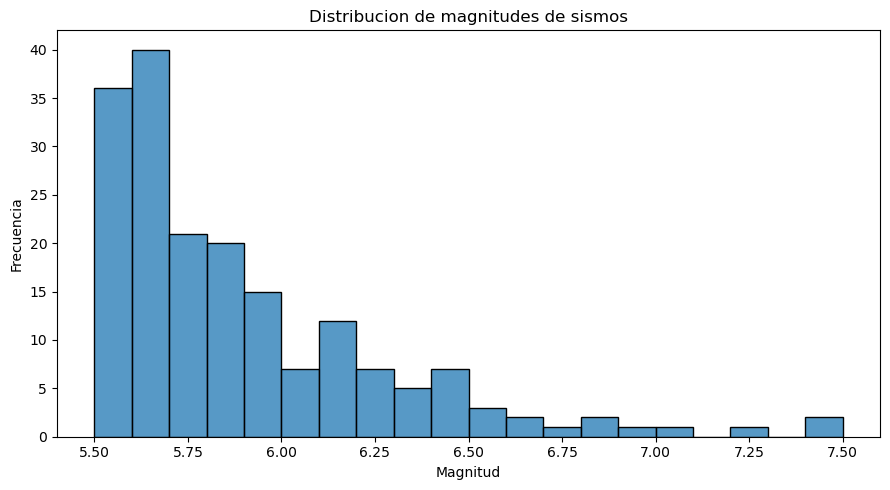

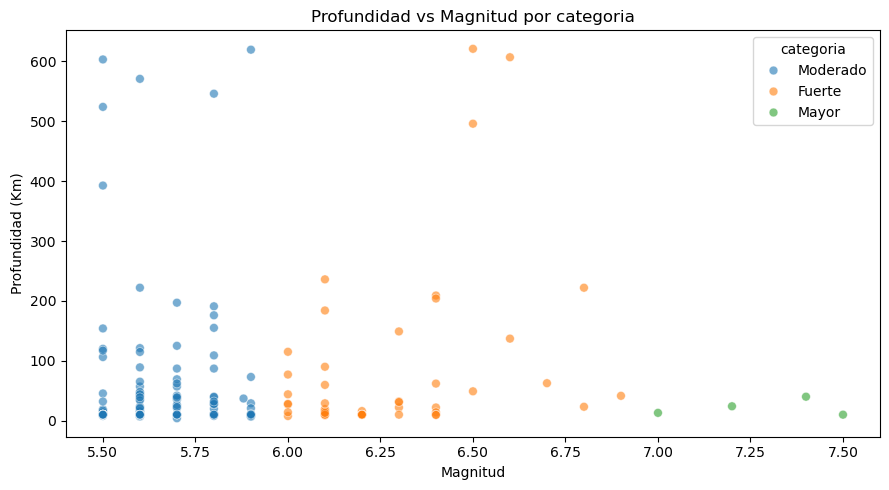

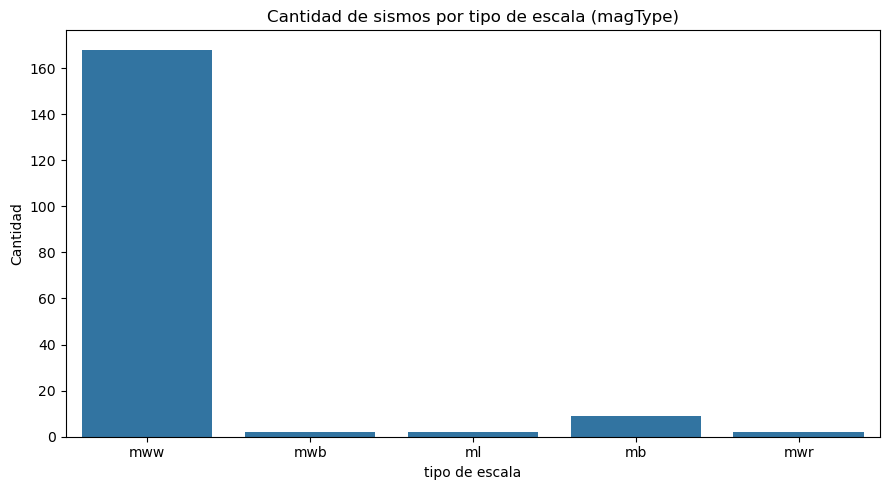

In [8]:
# ── Parte b) — Visualizaciones ───────────────────────────────────────────────
# Gráfica 1: Histograma de magnitudes
plt.figure(figsize=(9, 5))
sns.histplot(data=sismos, x='mag', bins=20)
# TU CÓDIGO AQUÍ
plt.title("Distribucion de magnitudes de sismos")
plt.xlabel("Magnitud")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Gráfica 2: Scatter profundidad vs magnitud coloreado por categoría
plt.figure(figsize=(9, 5))
sns.scatterplot(data=sismos, x='mag', y='depth', hue='categoria', s=40, alpha=0.6)
# TU CÓDIGO AQUÍ
plt.title("Profundidad vs Magnitud por categoria")
plt.xlabel("Magnitud")
plt.ylabel("Profundidad (Km)")
plt.tight_layout()
plt.show()

# Gráfica 3: Barras — cantidad de sismos por tipo de escala (magType)
plt.figure(figsize=(9, 5))
# Hint: obtén los conteos con sismos['magType'].value_counts()
#       luego grafica con .plot(kind='bar') o plt.bar() o sns.barplot()
# TU CÓDIGO AQUÍ
sns.countplot(data=sismos, x='magType')
plt.title("Cantidad de sismos por tipo de escala (magType)")
plt.xlabel("tipo de escala")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()


#### Preguntas de interpretación — Ejercicio 4

1. Según la función `analizar_sismos()`, completa:
   - Magnitud media: 5.847978142076505 
   - Magnitud máxima: 7.5
   - Tipo de escala más común (`magType`): mww  
   - Grandes terremotos (mag ≥ 7.0): 4

2. **Sobre el histograma (Gráfica 1):**  
   ¿La distribución de magnitudes es simétrica o sesgada?
   ¿Hacia qué lado se inclina y por qué tiene sentido físicamente?

   *Tu respuesta:* es sesgada y se inclina por el lado izquierdo donde esta la mayor concentracion de datos, debido a que los sismos de magnitud 5.5 y 5.75 son mucho mas frecuentes es por ello que por ese lado hay mas datos.

3. **Sobre el scatter plot (Gráfica 2):**  
   ¿Observas alguna relación entre la profundidad y la magnitud?
   ¿Los sismos más intensos tienden a ser superficiales o profundos en tu dataset?

   *Tu respuesta:* los sismos mas intensos son superficiales, ya que se agrupan en la parte inferios derecha de la grafica 

4. **Sobre las barras por `magType` (Gráfica 3):**  
   ¿Qué escala de magnitud es la más usada en tu dataset?
   Investiga brevemente: ¿para qué tipo de sismos se usa esa escala?

   *Tu respuesta:* la escala que se usa mas en el dataset es el mww (Magnitud de Momento basada en la fase W) se utliza para sismos de gran magnitud y de escala global. 

---
## Ejercicio 5 — Programación Orientada a Objetos (25 pts)

En el archivo `poo_sismos.py` encontrarás tres clases:

- **`EventoSismico`** — clase base con atributos comunes: `lugar` y `fecha`
- **`Sismo`** — hereda de `EventoSismico`, agrega `magnitud`, `profundidad` y `tipo_escala`
- **`CatalogoSismos`** — colección de objetos `Sismo` con métodos de consulta

**Paso 1:** Abre `poo_sismos.py` e implementa todos los métodos marcados con `# TU CÓDIGO AQUÍ`.  
**Paso 2:** Regresa aquí y ejecuta las celdas siguientes en orden.

| Parte | Tarea | Pts |
|---|---|:---:|
| a | 4 métodos de `Sismo`: `clasificar`, `clasificar_profundidad`, `es_peligroso`, `descripcion` | 10 |
| b | 3 métodos de `CatalogoSismos`: `el_mas_intenso`, `filtrar_por_categoria`, `resumen` | 10 |
| c | Ejecutar y responder las preguntas de interpretación | 5 |
| | **Subtotal** | **25** |

In [9]:
from poo_sismos import Sismo, CatalogoSismos

# Construir el catálogo con los primeros 50 sismos del DataFrame
catalogo = CatalogoSismos("URL_SISMOS")

for indice, fila in sismos.head(50).iterrows():
    s = Sismo(
        lugar       = fila['place'],
        fecha       = fila['time'],
        magnitud    = fila['mag'],
        profundidad = fila['depth'],
        tipo_escala = fila['magType'],
    )
    catalogo.agregar(s)

print(f"Catálogo creado con {len(catalogo)} sismos.\n")

# Muestra los primeros 3 usando __str__ (llama internamente a descripcion())
print("Primeros 3 sismos:")
for sismo in catalogo._sismos[:3]:
    print(" ", sismo)

Catálogo creado con 50 sismos.

Primeros 3 sismos:
  

TypeError: __str__ returned non-string (type NoneType)

In [ ]:
# Sismo más intenso del catálogo
mas_intenso = catalogo.el_mas_intenso()
print("Sismo más intenso del catálogo:")
print(" ", mas_intenso)
print(f"  ¿Es peligroso? → {mas_intenso.es_peligroso()}\n")

# Filtrar por categoría
mayores = catalogo.filtrar_por_categoria('Mayor')
print(f"Sismos de categoría 'Mayor' en los primeros 50: {len(mayores)}\n")

# Resumen completo
catalogo.resumen()

In [ ]:
# Verificación: clasificar() debe coincidir con la columna 'categoria' del Ejercicio 3.
print("Verificación POO vs. pandas (primeros 10 sismos):")
print(f"  {'mag':>6}  {'pandas Ej.3':>15}  {'POO clasificar()':>18}  {'':>4}")
print("  " + "─" * 52)

for i, (indice, fila) in enumerate(sismos.head(10).iterrows()):
    s = Sismo("", "", fila['mag'], fila['depth'])
    cat_poo    = s.clasificar()
    cat_pandas = fila['categoria']
    marca = "✓" if cat_poo == cat_pandas else "✗ REVISAR"
    print(f"  {fila['mag']:>6.2f}  {cat_pandas:>15}  {cat_poo:>18}  {marca}")

#### Preguntas de interpretación — Ejercicio 5

1. ¿Qué diferencia hay entre `EventoSismico` y `Sismo`?
   ¿Por qué `Sismo.__init__` llama a `super().__init__(lugar, fecha)`?

   *Tu respuesta:* ___

2. El método `clasificar()` de `Sismo` usa la misma lógica que la función
   `clasificar_sismo()` del Ejercicio 3. ¿Qué ventaja tiene implementarlo
   como método de una clase en lugar de como función suelta?

   *Tu respuesta:* ___

3. Según `catalogo.resumen()`:
   - ¿Cuántos sismos de categoría `'Mayor'` hay en los primeros 50? ___
   - ¿El sismo más intenso resultó peligroso (`es_peligroso() == True`)? ___
   - Justifica el resultado de `es_peligroso()` con los valores de magnitud y profundidad.

   *Tu respuesta:* ___

4. ¿Todos los `✓` aparecen en la celda de verificación?
   Si alguno muestra `✗`, ¿qué parte de tu método `clasificar()` necesita corrección?

   *Tu respuesta:* ___

---
## Pregunta final — Conclusiones (incluida en el punteo del Ejercicio 4)

Basándote en los datos analizados, escribe en la celda de abajo una conclusión
en tus propias palabras. Puedes guiarte con estas preguntas:

- ¿Cuál fue el sismo más intenso del período y qué tan severo fue según la escala?
- ¿Qué tipo de escala de magnitud (`magType`) predomina y por qué crees que es así?
- ¿Qué relación observas entre la profundidad y la magnitud en el scatter plot?


---
## Conclusión final

Basándote en **todos los valores que obtuviste** a lo largo del examen,
escribe un párrafo de al menos 5 oraciones que responda:

- ¿Qué caracteriza la actividad sísmica global del primer semestre de 2024
  según tu dataset personal?
- ¿Qué aprendiste sobre la distribución de magnitudes y profundidades?
- ¿Qué ventaja tiene usar pandas y NumPy sobre un ciclo `for` manual
  para este tipo de análisis? Da un ejemplo concreto de tu examen.

*(Escribe aquí tu respuesta — mínimo 5 oraciones)*




---
## Sello de entrega

Ejecuta la siguiente celda **como último paso**, justo antes de guardar y subir el notebook.

Registra la posición de la ISS en el momento exacto de tu entrega.
Dado que la ISS se desplaza ~7.7 km/s, dos estudiantes que entreguen
en momentos distintos obtendrán coordenadas completamente diferentes.

> Este sello es **único e irrepetible**: queda vinculado a tu carnet
> y al instante exacto en que ejecutaste la celda.


In [10]:
import requests as _req
from datetime import datetime, timezone

print("Consultando posicion de la ISS...")
try:
    r_iss  = _req.get("http://api.open-notify.org/iss-now.json", timeout=8)
    r_iss.raise_for_status()
    iss    = r_iss.json()
    iss_lat  = float(iss["iss_position"]["latitude"])
    iss_lon  = float(iss["iss_position"]["longitude"])
    iss_hora = datetime.fromtimestamp(iss["timestamp"], tz=timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")
    iss_ok   = True
except Exception as e:
    iss_lat, iss_lon, iss_hora = 0.0, 0.0, "no disponible"
    iss_ok = False
    print(f"  Advertencia: sin datos ISS ({e})")

ts = datetime.now(tz=timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")

print()
print("=" * 55)
print("        SELLO DE ENTREGA -- EXAMEN FINAL A")
print("=" * 55)
print(f"  Estudiante   : {NOMBRE}")
print(f"  Carnet       : {CARNET}")
print(f"  Fecha/Hora   : {ts}")
print(f"  ISS Latitud  : {iss_lat:+.4f} deg")
print(f"  ISS Longitud : {iss_lon:+.4f} deg")
print(f"  ISS Hora UTC : {iss_hora}")
print("=" * 55)


Consultando posicion de la ISS...
  Advertencia: sin datos ISS (HTTPConnectionPool(host='api.open-notify.org', port=80): Max retries exceeded with url: /iss-now.json (Caused by ConnectTimeoutError(<urllib3.connection.HTTPConnection object at 0x7bd0ef28ea50>, 'Connection to api.open-notify.org timed out. (connect timeout=8)')))

        SELLO DE ENTREGA -- EXAMEN FINAL A
  Estudiante   : Joselin Liseth Tzunux Coxaj
  Carnet       : 202606884
  Fecha/Hora   : 2026-05-19 01:06:55 UTC
  ISS Latitud  : +0.0000 deg
  ISS Longitud : +0.0000 deg
  ISS Hora UTC : no disponible


---
## Entrega

1. Ejecuta la celda **Sello de entrega** (arriba)
2. Guarda el notebook: **Archivo → Guardar** (o `Ctrl+S`)
3. Verifica que **todas las celdas tienen output** (ejecuta: **Kernel → Restart & Run All**)
4. Sube el archivo a tu repositorio en GitHub
5. Envía el enlace del notebook en el campo de entrega de **U Virtual**

> **Ruta esperada en tu repositorio:**  
> `examenes/python/examen_final/examen_final.ipynb`
